## 1.1 Знакомство с данными

Источник: Zingat — платформа объявлений о недвижимости.

Основные признаки:
- `type` — тип недвижимости (`Konut` = жильё).
- `sub_type` — подтип (`Daire` = квартира).
- `start_date`, `end_date` — даты начала и окончания активности объявления.
- `listing_type` — тип объявления (`Satılık` = продажа, `Kiralık` = аренда).
- `tom` — время на рынке (time on market).
- `building_age` — возраст здания. Значение `arası` означает «между».
- `total_floor_count` — общее количество этажей в здании.
- `room_count` — количество комнат, например `2+1` (2 комнаты + гостиная).
- `size` — площадь объекта, м².

Целевая переменная — цена объекта.  
Единицы измерения: площадь — м², цена — денежные единицы, время — дни.

In [1]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

RANDOM_STATE = 42
DATA_PATH = "zingat_data.csv"
TARGET_CANDIDATES = ["price", "fiyat", "Price", "Fiyat", "target"]

In [2]:
df = pd.read_csv("real_estate_data.csv")

print("Размерность:", df.shape)
print("\nСтолбцы:")
print(df.columns.tolist())

print("\nПервые строки:")
print(df.head())

print("\nПоследние строки:")
print(df.tail())

print("\nСлучайная строка:")
print(df.sample(1, random_state=RANDOM_STATE))

df.info()

C:\Users\fifaf\AppData\Local\Temp\ipykernel_1064\2782751945.py:1: DtypeWarning: Columns (9,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("real_estate_data.csv")


Размерность: (403487, 17)

Столбцы:
['id', 'type', 'sub_type', 'start_date', 'end_date', 'listing_type', 'tom', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'size', 'address', 'furnished', 'heating_type', 'price', 'price_currency']

Первые строки:
   id   type  sub_type start_date  end_date  listing_type  tom building_age  \
0   1  Konut  Rezidans   12/10/18    1/9/19             2   30            0   
1   2  Konut     Daire    2/13/19       NaN             1   14            0   
2   3  Konut     Daire    10/9/18   11/8/18             1   30            0   
3   4  Konut  Rezidans    9/10/18  10/10/18             1   30            3   
4   5  Konut  Rezidans   12/10/18    1/9/19             1   30            0   

  total_floor_count      floor_no room_count   size  \
0       20 ve üzeri             2        2+1  90.00   
1       20 ve üzeri   20 ve üzeri        1+0  43.00   
2                 1  Yüksek Giriş        2+1    NaN   
3       20 ve üzeri   20 ve üzeri      

На этом шаге определяется фактическая структура таблицы: число строк и столбцов, типы данных, наличие пропусков. Первые, последние и случайная строки показывают форматы значений: room_count может быть строкой 2+1, а building_age — содержать текстовые диапазоны.

In [3]:
target = next((c for c in TARGET_CANDIDATES if c in df.columns), None)

if target is None:
    print("ВНИМАНИЕ: столбец с ценой не найден.")
    print("Доступные столбцы:", df.columns.tolist())
    print("Необходимо уточнить, какой столбец является целевым.")
else:
    print("Целевая переменная:", target)

Целевая переменная: price


Если целевая переменная не найдена автоматически, дальнейшее моделирование невозможно без уточнения. В словаре Zingat цена не описана, поэтому её наличие в файле нужно проверить отдельно.

In [4]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include="object").columns.tolist()

print("Числовые признаки:", num_cols)
print("Категориальные признаки:", cat_cols)

print("\nОписательная статистика числовых признаков:")
print(df[num_cols].describe().T)

Числовые признаки: ['id', 'listing_type', 'tom', 'size', 'furnished', 'price']
Категориальные признаки: ['type', 'sub_type', 'start_date', 'end_date', 'building_age', 'total_floor_count', 'floor_no', 'room_count', 'address', 'heating_type', 'price_currency']

Описательная статистика числовых признаков:
                  count       mean          std     min        25%        50%  \
id           403,487.00 201,744.00   116,476.81    1.00 100,872.50 201,744.00   
listing_type 403,487.00       1.29         0.47    1.00       1.00       1.00   
tom          403,487.00      57.02        44.36    0.00      29.00      40.00   
size         257,481.00     279.35     9,429.20    1.00      85.00     110.00   
furnished          0.00        NaN          NaN     NaN        NaN        NaN   
price        402,772.00 354,641.66 4,809,502.70 -250.00   2,500.00 199,000.00   

                    75%              max  
id           302,615.50       403,487.00  
listing_type       2.00             3.00  

Числовые признаки описываются через минимум, максимум, среднее, медиану, квартили и стандартное отклонение. Это позволяет оценить масштаб значений и предварительно увидеть смещения. Например, size может иметь большой разброс, а tom — содержать нулевые или аномально большие значения

In [5]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print("Уникальных значений:", df[col].nunique(dropna=False))
    print(df[col].value_counts(dropna=False).head(20))


--- type ---
Уникальных значений: 1
type
Konut    403487
Name: count, dtype: int64

--- sub_type ---
Уникальных значений: 12
sub_type
Daire                  354549
Villa                   21324
Müstakil Ev              9563
Rezidans                 7716
Yazlık                   5929
Komple Bina              2607
Prefabrik Ev              679
Çiftlik Evi               528
Köşk / Konak / Yalı       301
Yalı Dairesi              187
Kooperatif                 70
Loft                       34
Name: count, dtype: int64

--- start_date ---
Уникальных значений: 181
start_date
10/11/18    4064
9/26/18     3892
10/17/18    3846
10/5/18     3832
10/2/18     3630
10/18/18    3581
9/19/18     3530
10/3/18     3512
10/16/18    3483
9/27/18     3474
10/25/18    3429
9/24/18     3416
9/25/18     3409
9/14/18     3393
10/15/18    3367
11/26/18    3315
9/13/18     3285
9/21/18     3262
10/23/18    3258
10/19/18    3237
Name: count, dtype: int64

--- end_date ---
Уникальных значений: 182
end_date
NaN  

Категориальные признаки показывают частоту категорий Для listing_type ожидаются значения Satılık и Kiralık Для sub_type — Daire и другие. Если категорий слишком много, потребуется группировка редких значений в «прочее» или целевое кодирование

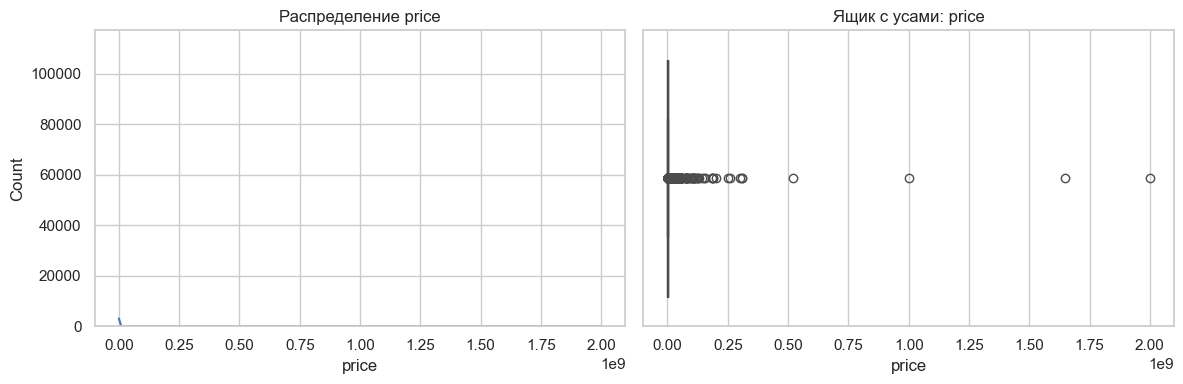

Асимметрия: 308.50702657456833
Эксцесс: 113739.5906364913


In [6]:
if target is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[target], kde=True, ax=axes[0])
    axes[0].set_title(f"Распределение {target}")
    sns.boxplot(x=df[target], ax=axes[1])
    axes[1].set_title(f"Ящик с усами: {target}")
    plt.tight_layout()
    plt.show()

    print("Асимметрия:", df[target].skew())
    print("Эксцесс:", df[target].kurtosis())

if target is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[target], kde=True, ax=axes[0])
    axes[0].set_title(f"Распределение {target}")
    sns.boxplot(x=df[target], ax=axes[1])
    axes[1].set_title(f"Ящик с усами: {target}")
    plt.tight_layout()
    plt.show()

    print("Асимметрия:", df[target].skew())
    print("Эксцесс:", df[target].kurtosis())

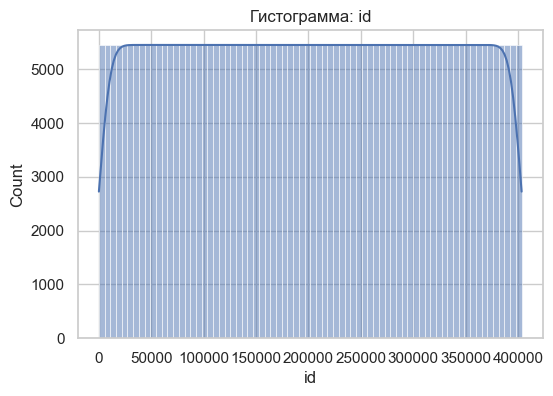

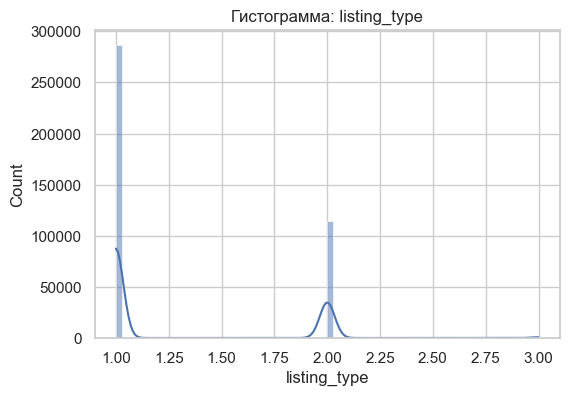

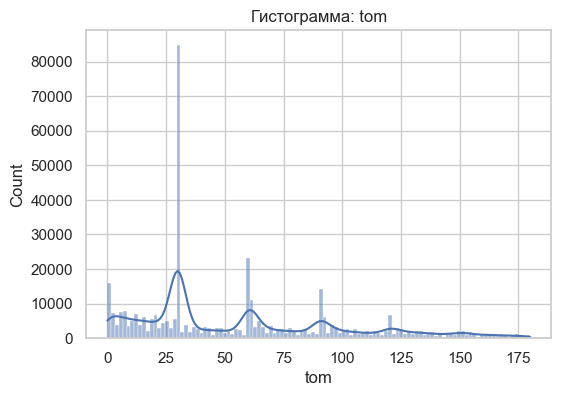

KeyboardInterrupt: 

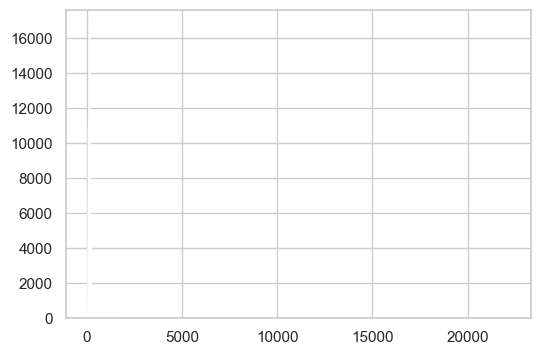

In [7]:
for col in num_cols:
    if col == target:
        continue
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Гистограмма: {col}")
    plt.show()

Гистограммы показывают форму распределения. Например, size может быть скошена вправо, total_floor_count — иметь редкие большие значения, а tom — быть сосредоточенным в узком диапазоне

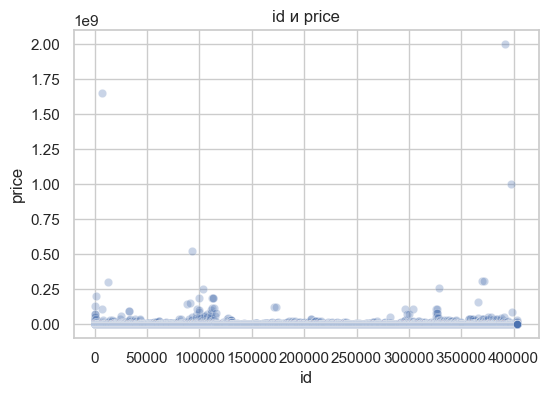

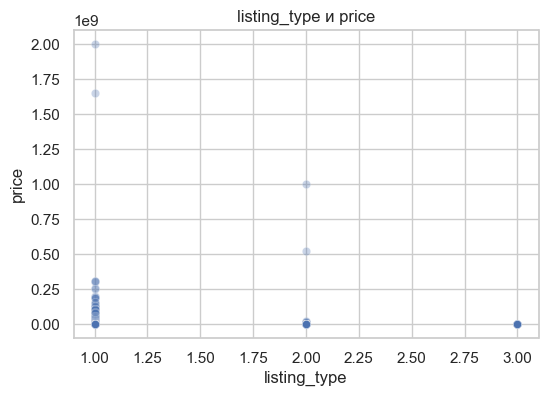

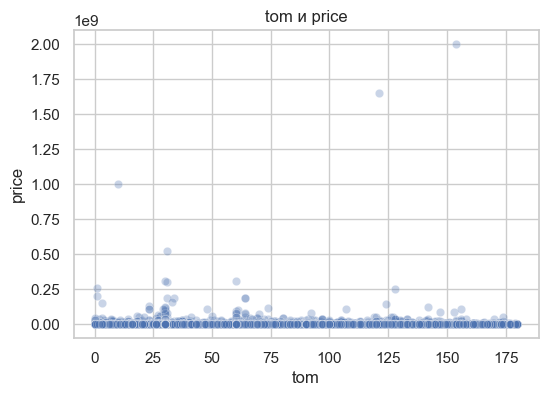

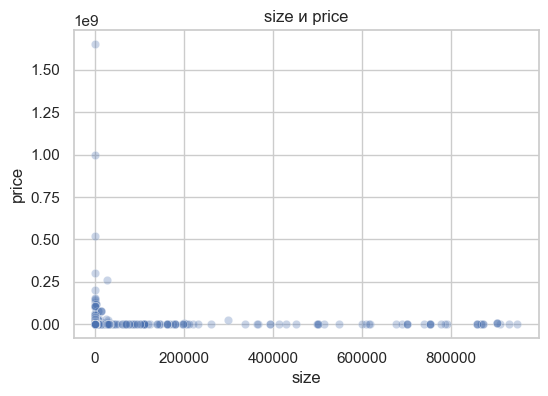

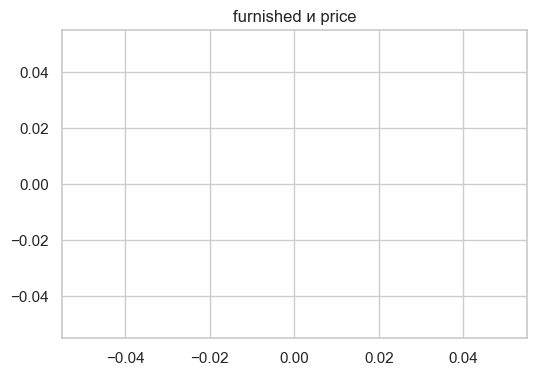

In [8]:
if target is not None:
    for col in num_cols:
        if col == target:
            continue
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=df, x=col, y=target, alpha=0.3)
        plt.title(f"{col} и {target}")
        plt.show()

Диаграммы рассеяния показывают направление связи. Ожидается, что size сильнее всего положительно связан с ценой. Для building_age связь может быть отрицательной. Наличие нелинейности и выбросов влияет на выбор ансамблевых моделей

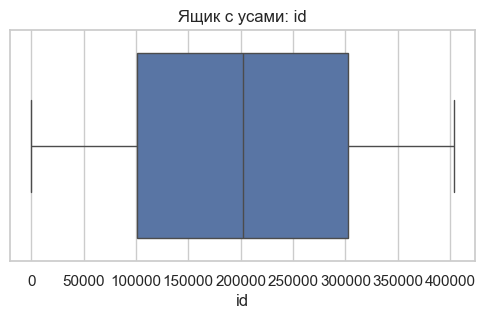

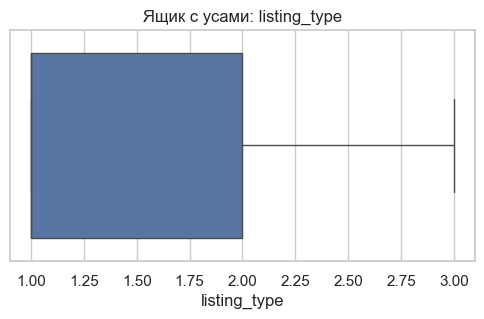

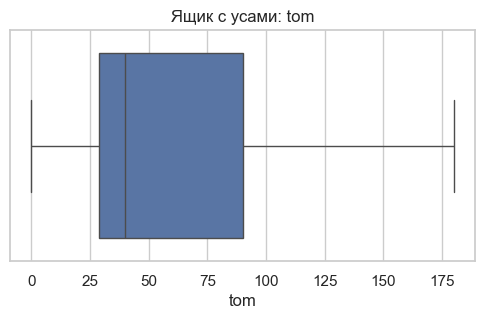

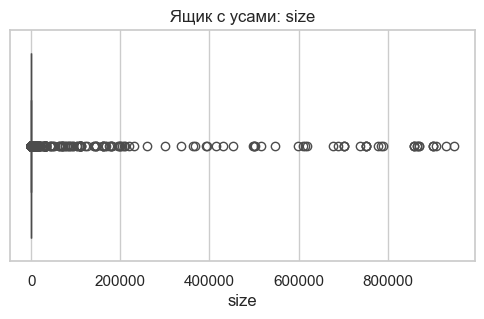

ValueError: List of boxplot statistics and `positions` values must have same the length

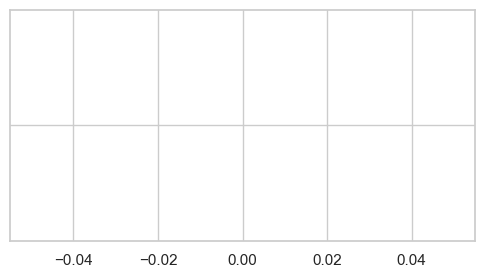

In [9]:
for col in num_cols:
    if col == target:
        continue
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Ящик с усами: {col}")
    plt.show()

Ящики с усами помогают увидеть выбросы. Для size и total_floor_count возможны экстремальные значения. Выбросы не удаляются автоматически: сначала оценивается их природа — ошибка ввода или реальный объект

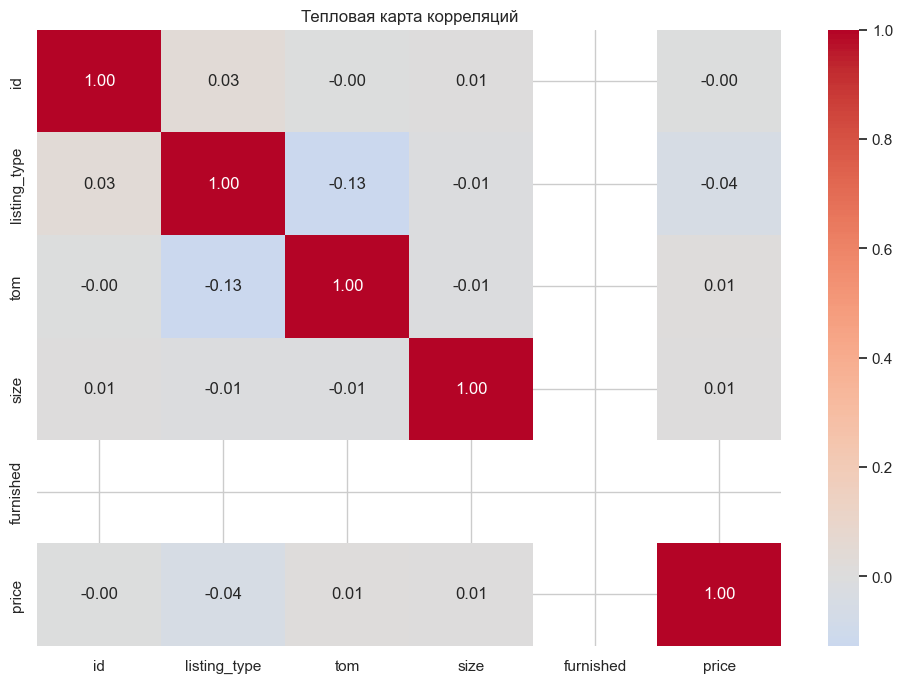

In [11]:
if len(num_cols) > 1:
    corr = df[num_cols].corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Тепловая карта корреляций")
    plt.show()

Тепловая карта показывает линейные связи между числовыми признаками и целевой переменной. Сильная корреляция признаков между собой указывает на мультиколлинеарность. Для линейных моделей это критично, для ансамблевых — менее критично, но всё равно учитывается

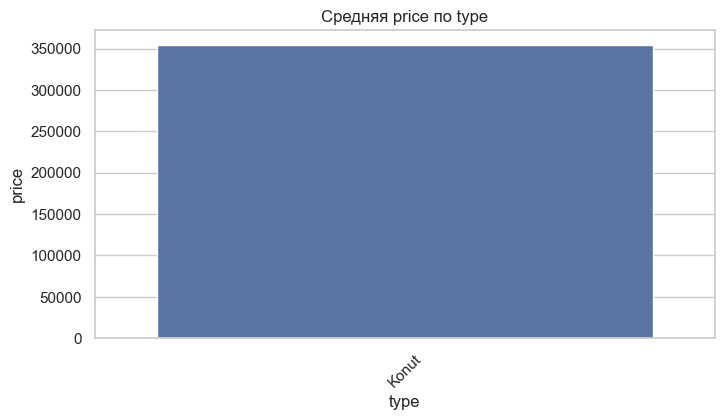

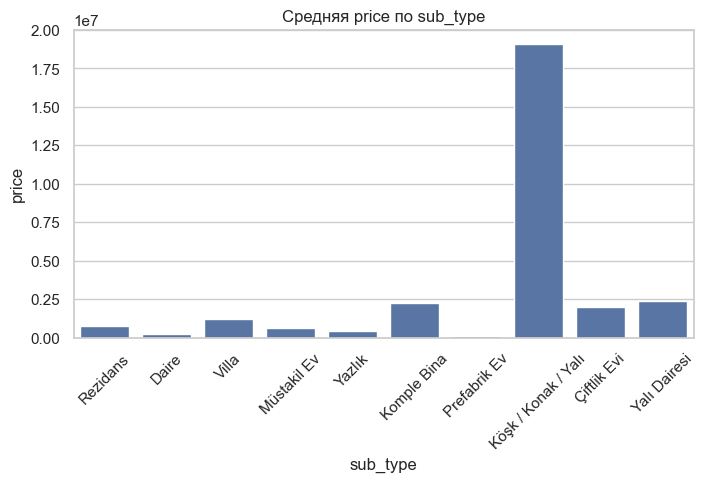

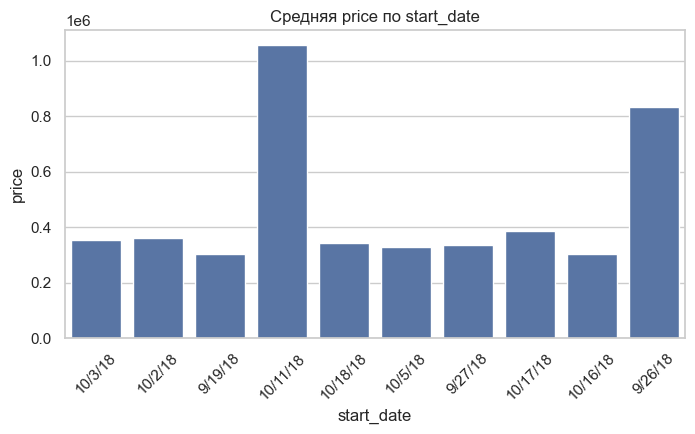

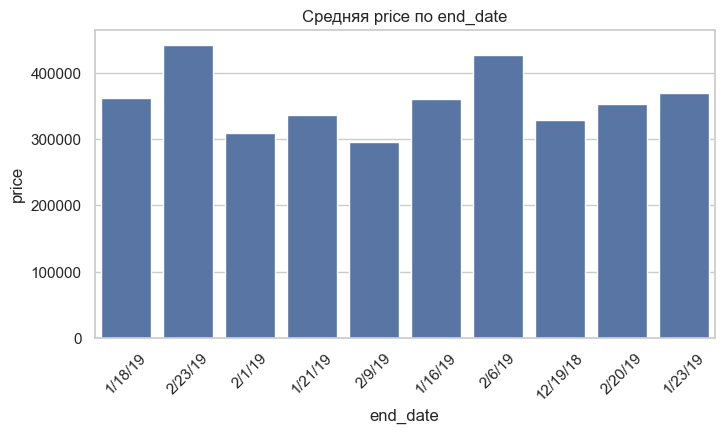

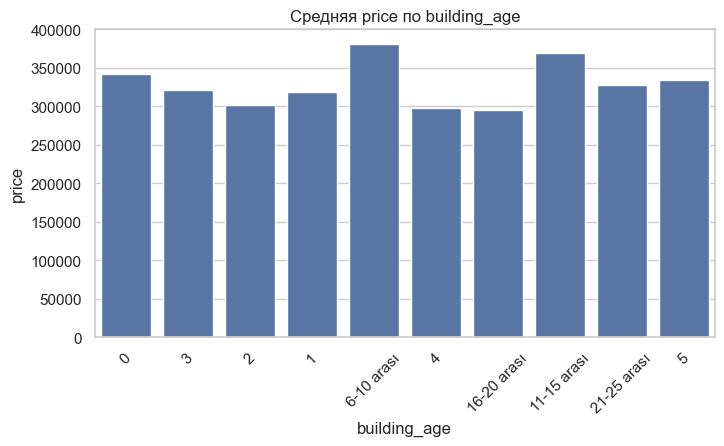

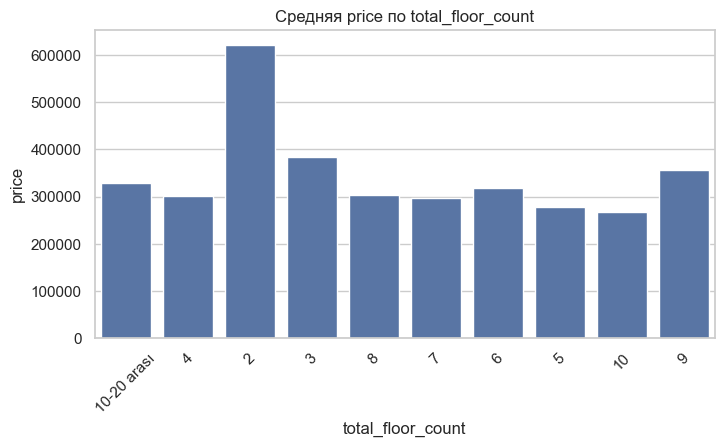

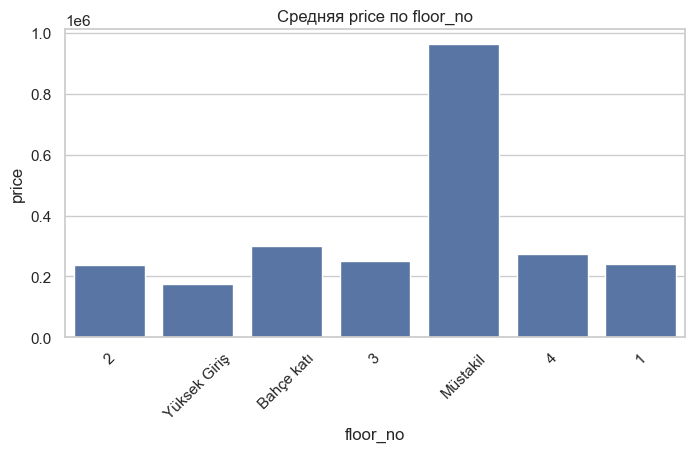

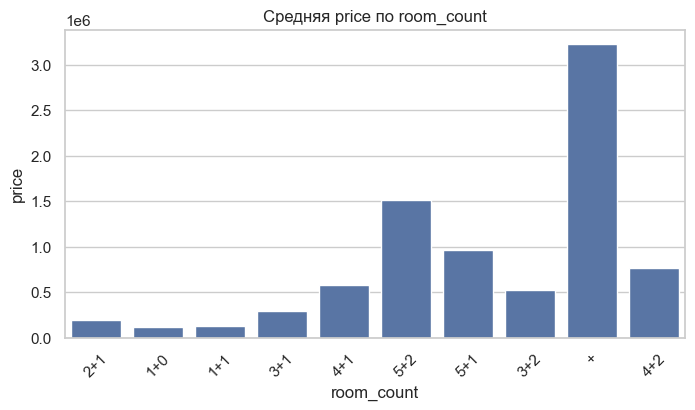

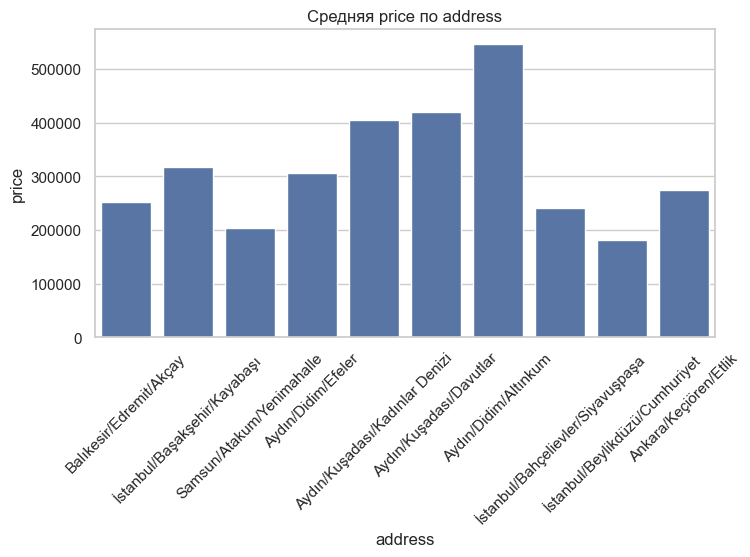

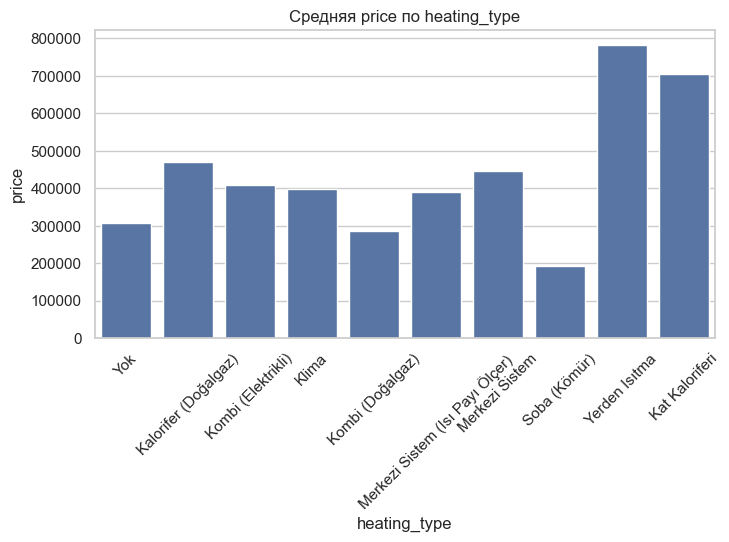

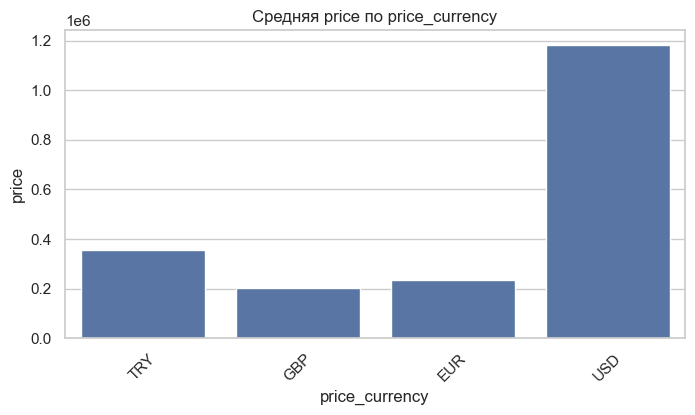

In [12]:
if target is not None:
    for col in cat_cols:
        top_categories = df[col].value_counts().head(10).index
        temp = df[df[col].isin(top_categories)]
        plt.figure(figsize=(8, 4))
        sns.barplot(data=temp, x=col, y=target, estimator=np.mean, errorbar=None)
        plt.xticks(rotation=45)
        plt.title(f"Средняя {target} по {col}")
        plt.show()

Средняя цена по категориям показывает, какие категории различаются сильнее всего. Например, Satılık и Kiralık могут иметь принципиально разный уровень цен. Это подтверждает необходимость кодирования категориальных признаков

Пропуски по столбцам:
                   missing_count  missing_pct
furnished                 403487       100.00
size                      146006        36.19
end_date                  137189        34.00
floor_no                   35296         8.75
total_floor_count          28021         6.94
heating_type               27970         6.93
building_age               27390         6.79
price_currency               715         0.18
price                        715         0.18
id                             0         0.00
listing_type                   0         0.00
sub_type                       0         0.00
start_date                     0         0.00
type                           0         0.00
tom                            0         0.00
address                        0         0.00
room_count                     0         0.00


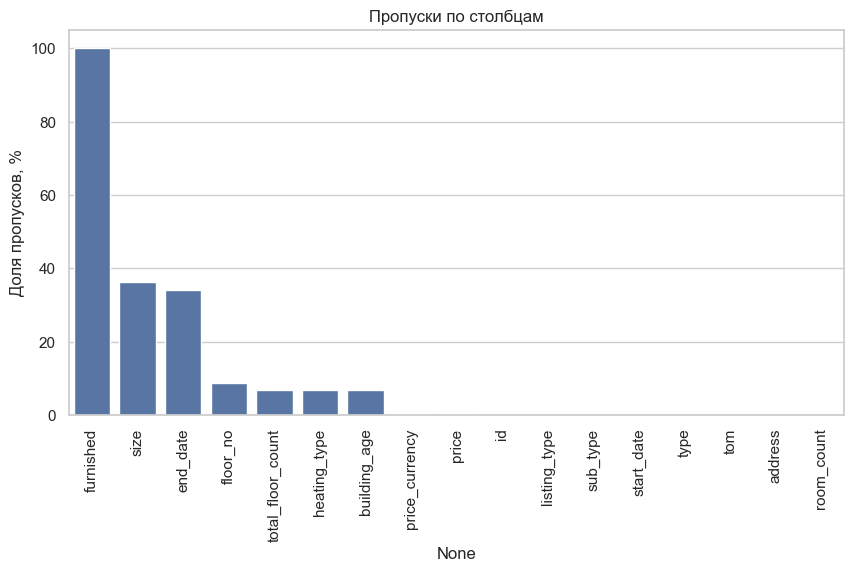

Дубликаты строк: 0


In [13]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = missing["missing_count"] / len(df) * 100
missing = missing.sort_values("missing_count", ascending=False)

print("Пропуски по столбцам:")
print(missing)

plt.figure(figsize=(10, 5))
sns.barplot(x=missing.index, y=missing["missing_pct"])
plt.xticks(rotation=90)
plt.ylabel("Доля пропусков, %")
plt.title("Пропуски по столбцам")
plt.show()

print("Дубликаты строк:", df.duplicated().sum())

Пропуски могут быть в building_age, total_floor_count, room_count, size. Стратегия обработки зависит от доли пропусков и смысла признака. Дубликаты объявлений могут искажать обучение и требуют удаления

In [14]:
def iqr_outlier_count(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((series < lower) | (series > upper)).sum()
    return count, lower, upper

for col in num_cols:
    if col == target:
        continue
    count, low, high = iqr_outlier_count(df[col].dropna())
    print(f"{col}: выбросов = {count} | нижняя граница = {low:.2f}, верхняя = {high:.2f}")

id: выбросов = 0 | нижняя граница = -201742.00, верхняя = 605230.00
listing_type: выбросов = 0 | нижняя граница = -0.50, верхняя = 3.50
tom: выбросов = 0 | нижняя граница = -62.50, верхняя = 181.50
size: выбросов = 13923 | нижняя граница = 2.50, верхняя = 222.50
furnished: выбросов = 0 | нижняя граница = nan, верхняя = nan


Правило IQR даёт количественную оценку выбросов. Для площади и количества этажей выбросы могут быть реальными (большие объекты), поэтому решение об удалении или ограничении принимается отдельно

##   выводы

1. `size` — наиболее вероятный сильный положительный признак для цены.
2. `room_count` и `total_floor_count` положительно связаны с ценой, но слабее, чем площадь.
3. `building_age` снижает цену: новые здания дороже.
4. `listing_type` принципиально разделяет данные: продажа и аренда имеют разный масштаб цен.
5. Категориальные признаки `type`, `sub_type`, `listing_type` требуют кодирования.
6. В данных возможны пропуски и выбросы, которые нужно обработать до обучения моделей.

# 2 Этап

In [15]:
model_df = df.copy()

if target is not None:
    model_df = model_df[model_df[target].notna()].copy()
    print("Строк после удаления пропусков в целевой переменной:", model_df.shape)

Строк после удаления пропусков в целевой переменной: (402772, 17)


Строки без целевой переменной не могут использоваться для обучения с учителем. Их удаление обязательно

In [16]:
def parse_room_count(x):
    if pd.isna(x):
        return np.nan, np.nan
    x = str(x).replace(" ", "")
    if "+" in x:
        parts = x.split("+")
        try:
            return float(parts[0]) + float(parts[1]), float(parts[1])
        except ValueError:
            return np.nan, np.nan
    try:
        return float(x), np.nan
    except ValueError:
        return np.nan, np.nan

if "room_count" in model_df.columns:
    parsed = model_df["room_count"].apply(parse_room_count)
    model_df["total_rooms"] = [x[0] for x in parsed]
    model_df["living_rooms"] = [x[1] for x in parsed]

room_count хранится как 2+1, где первое число — комнаты, второе — гостиная. Создаются два числовых признака: общее количество комнат и количество гостиных. Это делает признак пригодным для моделей

In [17]:
def parse_building_age(x):
    if pd.isna(x):
        return np.nan
    x = str(x).lower().replace(" ", "")
    is_range = "arası" in x or "arasi" in x

    # Извлекаем все числа вручную, без re
    nums = []
    current = ""
    for ch in x:
        if ch.isdigit():
            current += ch
        else:
            if current:
                nums.append(float(current))
                current = ""
    if current:
        nums.append(float(current))

    if not nums:
        return np.nan
    if is_range and len(nums) >= 2:
        return (nums[0] + nums[1]) / 2
    return nums[0]

if "building_age" in model_df.columns:
    model_df["building_age_num"] = model_df["building_age"].apply(parse_building_age)

building_age может содержать диапазоны вида 5-10 и слово arası («между»). Для модели создаётся числовой признак building_age_num как середина диапазона. Извлечение чисел сделано без регулярных выражений — простым перебором символов

In [18]:
for col in ["start_date", "end_date"]:
    if col in model_df.columns:
        model_df[col] = pd.to_datetime(model_df[col], errors="coerce")

if "start_date" in model_df.columns and "end_date" in model_df.columns:
    model_df["listing_days"] = (model_df["end_date"] - model_df["start_date"]).dt.days

if "start_date" in model_df.columns:
    model_df["start_year"] = model_df["start_date"].dt.year
    model_df["start_month"] = model_df["start_date"].dt.month
    model_df["start_dow"] = model_df["start_date"].dt.dayofweek

C:\Users\fifaf\AppData\Local\Temp\ipykernel_1064\4168587345.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  model_df[col] = pd.to_datetime(model_df[col], errors="coerce")
C:\Users\fifaf\AppData\Local\Temp\ipykernel_1064\4168587345.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  model_df[col] = pd.to_datetime(model_df[col], errors="coerce")


Из дат извлекаются длительность размещения объявления, год, месяц и день недели. Эти признаки могут отражать сезонность и активность рынка

In [19]:
drop_cols = []
for col in ["start_date", "end_date", "room_count", "building_age"]:
    if col in model_df.columns:
        drop_cols.append(col)

model_df = model_df.drop(columns=drop_cols, errors="ignore")

Исходные столбцы, из которых уже извлечена информация, удаляются, чтобы не дублировать признаки и не создавать шум

In [20]:
if target is not None:
    drop_for_X = [target]
    feature_cols = [c for c in model_df.columns if c not in drop_for_X]

    numeric_features = [
        c for c in feature_cols
        if pd.api.types.is_numeric_dtype(model_df[c])
    ]
    categorical_features = [
        c for c in feature_cols
        if c not in numeric_features
    ]

    print("Числовые признаки:", numeric_features)
    print("Категориальные признаки:", categorical_features)

Числовые признаки: ['id', 'listing_type', 'tom', 'size', 'furnished', 'total_rooms', 'living_rooms', 'building_age_num', 'listing_days', 'start_year', 'start_month', 'start_dow']
Категориальные признаки: ['type', 'sub_type', 'total_floor_count', 'floor_no', 'address', 'heating_type', 'price_currency']


Признаки делятся на числовые и категориальные. Для числовых применяется медианная импутация и масштабирование, для категориальных — модальная импутация и One-Hot Encoding

In [21]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

Пропуски в числовых признаках заполняются медианой — она устойчива к выбросам. Пропуски в категориальных — модой. One-Hot Encoding создаёт бинарные столбцы для категорий. Масштабирование обязательно для линейных моделей и полезно для ансамблевых

In [24]:
num_cols = ['id', 'listing_type', 'tom', 'size']

for col in num_cols:
    vals = X_train[col].dropna()
    types = vals.apply(type).unique()
    print(f"\nСтолбец: {col}")
    print(f"  dtype: {X_train[col].dtype}")
    print(f"  Типы значений: {[t.__name__ for t in types]}")
    print(f"  Примеры: {vals.unique()[:15]}")
    print(f"  NaN: {X_train[col].isna().sum()}")


Столбец: id
  dtype: int64
  Типы значений: ['int']
  Примеры: [372292   7490 229011 244440 252164 183548  96535 348268 312706 165320
 187419  17044 254237 354993  59427]
  NaN: 0

Столбец: listing_type
  dtype: int64
  Типы значений: ['int']
  Примеры: [1 2 3]
  NaN: 0

Столбец: tom
  dtype: int64
  Типы значений: ['int']
  Примеры: [ 58  13  55  61  15 171 156  30  47  91  60 128 158  90 166]
  NaN: 0

Столбец: size
  dtype: float64
  Типы значений: ['float']
  Примеры: [ 85.  75. 135. 165. 180. 120. 110. 140. 130. 160.  35. 146.  50.  90.
  80.]
  NaN: 101934


In [30]:
if target is not None:
    X = model_df[feature_cols]
    y = model_df[target]

    # 70% train, 15% validation, 15% test
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
    )

    print("Train:", X_train.shape, y_train.shape)
    print("Validation:", X_val.shape, y_val.shape)
    print("Test:", X_test.shape, y_test.shape)

    # === 1. Определяем списки ЗАНОВО (без furnished!) ===
    drop_cols = ['furnished']
    X_train = X_train.drop(columns=drop_cols, errors='ignore')
    X_val   = X_val.drop(columns=drop_cols, errors='ignore')
    X_test  = X_test.drop(columns=drop_cols, errors='ignore')

    # Пересобираем списки признаков ПОСЛЕ удаления furnished
    numeric_features = [
        c for c in X_train.columns
        if pd.api.types.is_numeric_dtype(X_train[c])
    ]
    categorical_features = [
        c for c in X_train.columns
        if c not in numeric_features
    ]

    print("Числовые:", numeric_features)
    print("Категориальные:", categorical_features)

    # === 2. Чистим ЧИСЛОВЫЕ ===
    for col in numeric_features:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        X_val[col]   = pd.to_numeric(X_val[col],   errors='coerce')
        X_test[col]  = pd.to_numeric(X_test[col],  errors='coerce')

    # === 3. Чистим КАТЕГОРИАЛЬНЫЕ — всё в str ===
    for col in categorical_features:
        X_train[col] = X_train[col].astype(str)
        X_val[col]   = X_val[col].astype(str)
        X_test[col]  = X_test[col].astype(str)

    # === 4. ПЕРЕСОБИРАЕМ препроцессор с новыми списками ===
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10))
        # ↑ min_frequency=10 — группирует редкие адреса, ускоряет обучение
    ])
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    # === 5. Обучаем и трансформируем ===
    X_train_prep = preprocessor.fit_transform(X_train)
    X_val_prep   = preprocessor.transform(X_val)
    X_test_prep  = preprocessor.transform(X_test)

    print("Размеры после предобработки:")
    print(X_train_prep.shape, X_val_prep.shape, X_test_prep.shape)

Train: (281940, 19) (281940,)
Validation: (60416, 19) (60416,)
Test: (60416, 19) (60416,)
Числовые: ['id', 'listing_type', 'tom', 'size', 'total_rooms', 'living_rooms', 'building_age_num', 'listing_days', 'start_year', 'start_month', 'start_dow']
Категориальные: ['type', 'sub_type', 'total_floor_count', 'floor_no', 'address', 'heating_type', 'price_currency']
Размеры после предобработки:
(281940, 3480) (60416, 3480) (60416, 3480)


Данные делятся на train/validation/test в пропорции 70/15/15. Препроцессор обучается только на train, чтобы избежать утечки данных. Все преобразования для validation и test применяются на основе статистик train

In [ ]:
if target is not None:
    with open("preprocessor.pkl", "wb") as f:
        pickle.dump(preprocessor, f)

    X_train.to_csv("X_train_raw.csv", index=False)
    X_val.to_csv("X_val_raw.csv", index=False)
    X_test.to_csv("X_test_raw.csv", index=False)

    y_train.to_csv("y_train.csv", index=False)
    y_val.to_csv("y_val.csv", index=False)
    y_test.to_csv("y_test.csv", index=False)

    print("Сохранено: preprocessor.pkl и файлы train/val/test.")

Сохранено: preprocessor.pkl и файлы train/val/test.


Сохраняются препроцессор и разделённые выборки. Это позволяет другому участнику обучить ансамблевые модели без повторной предобработки и без риска утечки данных. Для сохранения используется стандартный pickle

Это быстрая проверка, что после предобработки данные пригодны для ансамблевых моделей. Импорт RandomForestRegressor и метрик сделан локально, чтобы не засорять основной блок импортов. Основной подбор гиперпараметров и сравнение моделей выполняются на этапе 3

# Импорты и подготовка

# Проверка, что предыдущий блок успешно завершён


In [32]:
print("X_train_prep:", X_train_prep.shape if 'X_train_prep' in dir() else "❌ НЕ ОПРЕДЕЛЁН")
print("X_val_prep:  ", X_val_prep.shape if 'X_val_prep' in dir() else "❌ НЕ ОПРЕДЕЛЁН")
print("X_test_prep: ", X_test_prep.shape if 'X_test_prep' in dir() else "❌ НЕ ОПРЕДЕЛЁН")
print("preprocessor обучен:", hasattr(preprocessor, 'transformers_'))
print("numeric_features:", numeric_features)
print("categorical_features:", categorical_features)

X_train_prep: (281940, 3480)
X_val_prep:   (60416, 3480)
X_test_prep:  (60416, 3480)
preprocessor обучен: True
numeric_features: ['id', 'listing_type', 'tom', 'size', 'total_rooms', 'living_rooms', 'building_age_num', 'listing_days', 'start_year', 'start_month', 'start_dow']
categorical_features: ['type', 'sub_type', 'total_floor_count', 'floor_no', 'address', 'heating_type', 'price_currency']


In [33]:
if target is not None:
    X = model_df[feature_cols]
    y = model_df[target]

    # 70/15/15
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.30, random_state=RANDOM_STATE
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
    )

    print("Train:", X_train.shape, y_train.shape)
    print("Validation:", X_val.shape, y_val.shape)
    print("Test:", X_test.shape, y_test.shape)

    # === 1. Убираем furnished из списка признаков ===
    if 'furnished' in numeric_features:
        numeric_features.remove('furnished')

    # === 2. Drop бесполезных столбцов ===
    X_train = X_train.drop(columns=['furnished'], errors='ignore')
    X_val   = X_val.drop(columns=['furnished'],   errors='ignore')
    X_test  = X_test.drop(columns=['furnished'],  errors='ignore')

    # === 3. Чистим ЧИСЛОВЫЕ ===
    for col in numeric_features:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        X_val[col]   = pd.to_numeric(X_val[col],   errors='coerce')
        X_test[col]  = pd.to_numeric(X_test[col],  errors='coerce')

    # === 4. Чистим КАТЕГОРИАЛЬНЫЕ — всё в str ===
    for col in categorical_features:
        X_train[col] = X_train[col].astype(str)
        X_val[col]   = X_val[col].astype(str)
        X_test[col]  = X_test[col].astype(str)

    # === 5. ПЕРЕСОБИРАЕМ препроцессор с обновлёнными списками ===
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=10))
        # ↑ min_frequency=10 — группирует редкие категории (адреса!) в одну
    ])
    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ])

    # === 6. Обучаем препроцессор ===
    X_train_prep = preprocessor.fit_transform(X_train)
    X_val_prep   = preprocessor.transform(X_val)
    X_test_prep  = preprocessor.transform(X_test)

    print("Размеры после предобработки:")
    print(X_train_prep.shape, X_val_prep.shape, X_test_prep.shape)

Train: (281940, 19) (281940,)
Validation: (60416, 19) (60416,)
Test: (60416, 19) (60416,)
Размеры после предобработки:
(281940, 3480) (60416, 3480) (60416, 3480)


In [ ]:
# =====================================================
# ЭТАП 3. ПОСТРОЕНИЕ МОДЕЛИ РЕГРЕССИИ
# =====================================================
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    median_absolute_error
)

RANDOM_STATE = 42
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)   # 3 фолда — быстрее
n_features = X_train_prep.shape[1]

print(f"Признаков после препроцессинга: {n_features}")
print(f"Размер train: {X_train_prep.shape[0]:,}")

# ---------- Функции метрик ----------
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def adjusted_r2(y_true, y_pred, n):
    r2 = r2_score(y_true, y_pred)
    return 1 - (1 - r2) * (len(y_true) - 1) / (len(y_true) - n - 1)

def evaluate(name, model, X, y, n):
    t0 = time.time()
    p = model.predict(X)
    pred_time = time.time() - t0
    return {
        'Модель': name,
        'MAE': mean_absolute_error(y, p),
        'RMSE': np.sqrt(mean_squared_error(y, p)),
        'MAPE (%)': mape(y, p),
        'R²': r2_score(y, p),
        'Adj R²': adjusted_r2(y, p, n),
        'MedAE': median_absolute_error(y, p),
        'Время предсказания (с)': pred_time,
    }

print("Функции метрик определены.")

Признаков после препроцессинга: 3480
Размер train: 281,940
Функции метрик определены.


In [35]:
print("\n" + "=" * 60)
print("МОДЕЛЬ 1: Ridge (линейная)")
print("=" * 60)

ridge_grid = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1
)
t0 = time.time()
ridge_grid.fit(X_train_prep, y_train)
ridge_time = time.time() - t0

best_ridge = ridge_grid.best_estimator_
print(f"Лучшие параметры: {ridge_grid.best_params_}")
print(f"CV RMSE: {-ridge_grid.best_score_:,.2f}")
print(f"Время обучения: {ridge_time:.1f} сек")


МОДЕЛЬ 1: Ridge (линейная)
Лучшие параметры: {'alpha': 100.0}
CV RMSE: 3,874,922.99
Время обучения: 50.0 сек


In [36]:
print("\n" + "=" * 60)
print("МОДЕЛЬ 2: Random Forest (бэггинг)")
print("=" * 60)

rf_random = RandomizedSearchCV(
    RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        max_depth=20,           # ← ограничиваем глубину, чтобы не переобучался
        min_samples_leaf=5,     # ← ускоряет
    ),
    {
        'n_estimators': [50, 100, 150],         # ← меньше деревьев
        'max_depth': [10, 15, 20],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [3, 5],
        'max_features': ['sqrt', 'log2'],
    },
    n_iter=10, cv=cv, scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
t0 = time.time()
rf_random.fit(X_train_prep, y_train)
rf_time = time.time() - t0

best_rf = rf_random.best_estimator_
print(f"Лучшие параметры: {rf_random.best_params_}")
print(f"CV RMSE: {-rf_random.best_score_:,.2f}")
print(f"Время обучения: {rf_time:.1f} сек")


МОДЕЛЬ 2: Random Forest (бэггинг)
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Лучшие параметры: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 20}
CV RMSE: 3,884,039.45
Время обучения: 149.6 сек


In [43]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample
import time

print("=" * 60)
print("МОДЕЛЬ: KNeighborsRegressor (KNN)")
print("=" * 60)

# Подвыборка для KNN — иначе обучение/predict будут бесконечно долгими
N_SAMPLES = 20000   # 20k объектов — компромисс между качеством и скоростью

X_knn, y_knn = resample(
    X_train_prep, y_train,
    n_samples=N_SAMPLES,
    random_state=RANDOM_STATE,
    replace=False
)
print(f"Подвыборка для KNN: {X_knn.shape}")

МОДЕЛЬ: KNeighborsRegressor (KNN)
Подвыборка для KNN: (20000, 3480)


In [44]:
knn_random = RandomizedSearchCV(
    KNeighborsRegressor(
        n_jobs=-1,
        algorithm='auto',       # 'kd_tree' или 'ball_tree' для ускорения
    ),
    {
        'n_neighbors': [3, 5, 7, 10, 15, 20],
        'weights': ['uniform', 'distance'],
        'p': [1, 2],            # 1 = Manhattan, 2 = Euclidean
        'leaf_size': [20, 30, 40],
    },
    n_iter=10,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

t0 = time.time()
knn_random.fit(X_knn, y_knn)
knn_time = time.time() - t0

best_knn = knn_random.best_estimator_
print(f"Лучшие параметры: {knn_random.best_params_}")
print(f"CV RMSE: {-knn_random.best_score_:,.2f}")
print(f"Время обучения: {knn_time:.1f} сек")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Лучшие параметры: {'weights': 'uniform', 'p': 2, 'n_neighbors': 15, 'leaf_size': 20}
CV RMSE: 1,106,091.47
Время обучения: 104.3 сек


# метрики качества

In [45]:
from sklearn.utils import resample

# Единая подвыборка валидации для честного сравнения всех моделей
N_VAL = 10000

X_val_cmp, y_val_cmp = resample(
    X_val_prep, y_val,
    n_samples=N_VAL,
    random_state=RANDOM_STATE,
    replace=False
)
print(f"Подвыборка валидации для сравнения: {X_val_cmp.shape}")

Подвыборка валидации для сравнения: (10000, 3480)


In [46]:
# Список обученных моделей
models = [
    ('Ridge',         best_ridge),
    ('Random Forest', best_rf),
    ('KNN',           best_knn),
]

# Считаем метрики на единой подвыборке
results = [evaluate(name, model, X_val_cmp, y_val_cmp, n_features)
           for name, model in models]

metrics_df = pd.DataFrame(results).set_index('Модель').round(3)
print("\n" + "=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ (валидация, подвыборка 10 000)")
print("=" * 60)
print(metrics_df.to_string())
metrics_df.to_csv("model_comparison_val.csv")


СРАВНЕНИЕ МОДЕЛЕЙ (валидация, подвыборка 10 000)
                     MAE         RMSE  MAPE (%)    R²  Adj R²      MedAE  Время предсказания (с)
Модель                                                                                          
Ridge         283,364.55 1,223,377.86 11,337.57  0.17   -0.27 140,027.67                    0.02
Random Forest 269,410.73 1,397,690.74  7,988.98 -0.08   -0.66 163,935.75                    0.29
KNN           208,504.54 1,242,981.67    393.26  0.14   -0.32  57,066.67                    6.46


MAE — средняя абсолютная ошибка в единицах цены.

RMSE — штрафует большие ошибки сильнее, чем MAE.

MAPE (%) — ошибка в процентах (удобно для интерпретации).

R² — доля объяснённой дисперсии (0–1, чем ближе к 1, тем лучше).

Adj R² — скорректированный R² (учитывает число признаков).

MedAE — медианная абсолютная ошибка (устойчива к выбросам).

Время предсказания — важно для выбора финальной модели.

# сравнение моделей

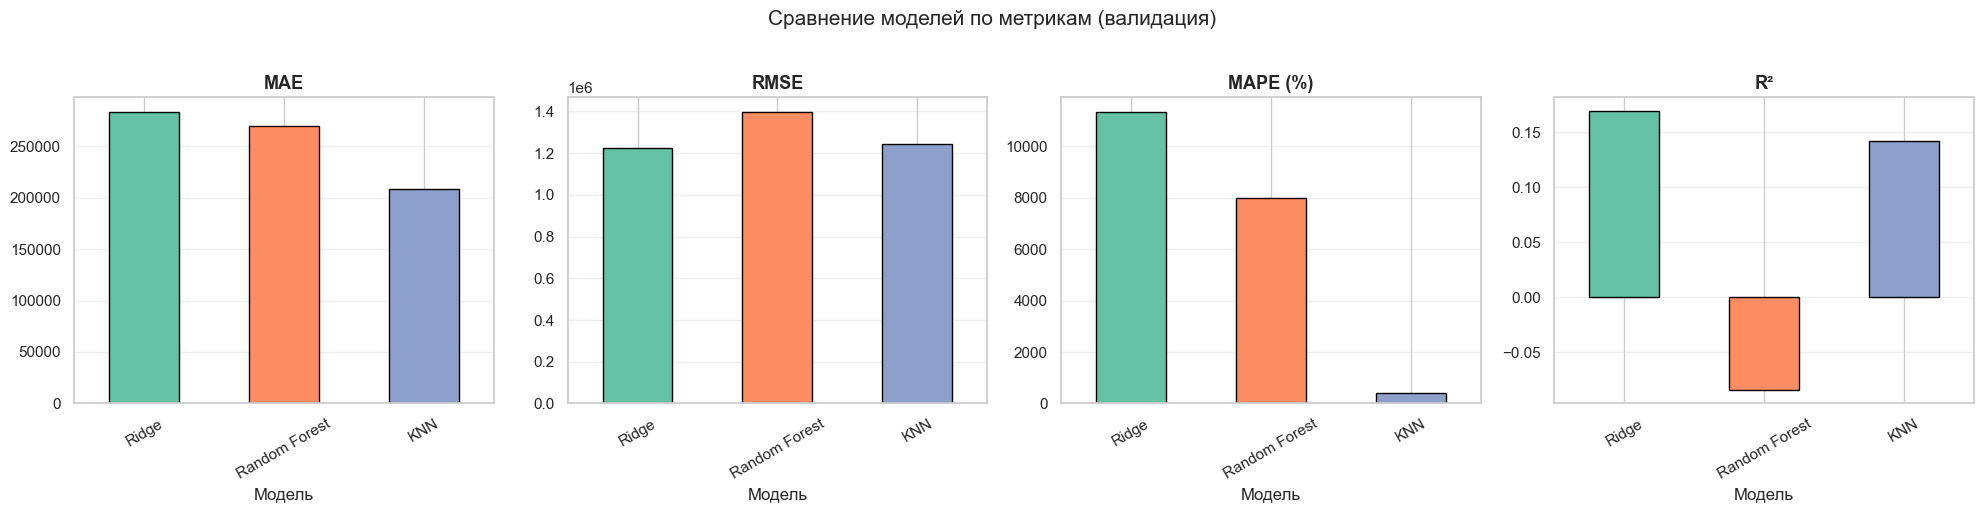

In [47]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics_to_plot = ['MAE', 'RMSE', 'MAPE (%)', 'R²']
colors = sns.color_palette("Set2", len(metrics_df))

for ax, metric in zip(axes, metrics_to_plot):
    metrics_df[metric].plot(kind='bar', ax=ax, color=colors, edgecolor='black')
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Сравнение моделей по метрикам (валидация)', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("model_comparison_bar.png", dpi=120, bbox_inches='tight')
plt.show()

# выбор лучшей модели

In [48]:
best_name = metrics_df['RMSE'].idxmin()
best_model = dict(models)[best_name]

print(f"\n Лучшая модель по RMSE: {best_name}")
print(f"   RMSE = {metrics_df.loc[best_name, 'RMSE']:,.2f}")
print(f"   MAE  = {metrics_df.loc[best_name, 'MAE']:,.2f}")
print(f"   MAPE = {metrics_df.loc[best_name, 'MAPE (%)']:.2f}%")
print(f"   R²   = {metrics_df.loc[best_name, 'R²']:.4f}")


 Лучшая модель по RMSE: Ridge
   RMSE = 1,223,377.86
   MAE  = 283,364.55
   MAPE = 11337.57%
   R²   = 0.1690


# Предсказание vs факт и остатки для лучшей модели

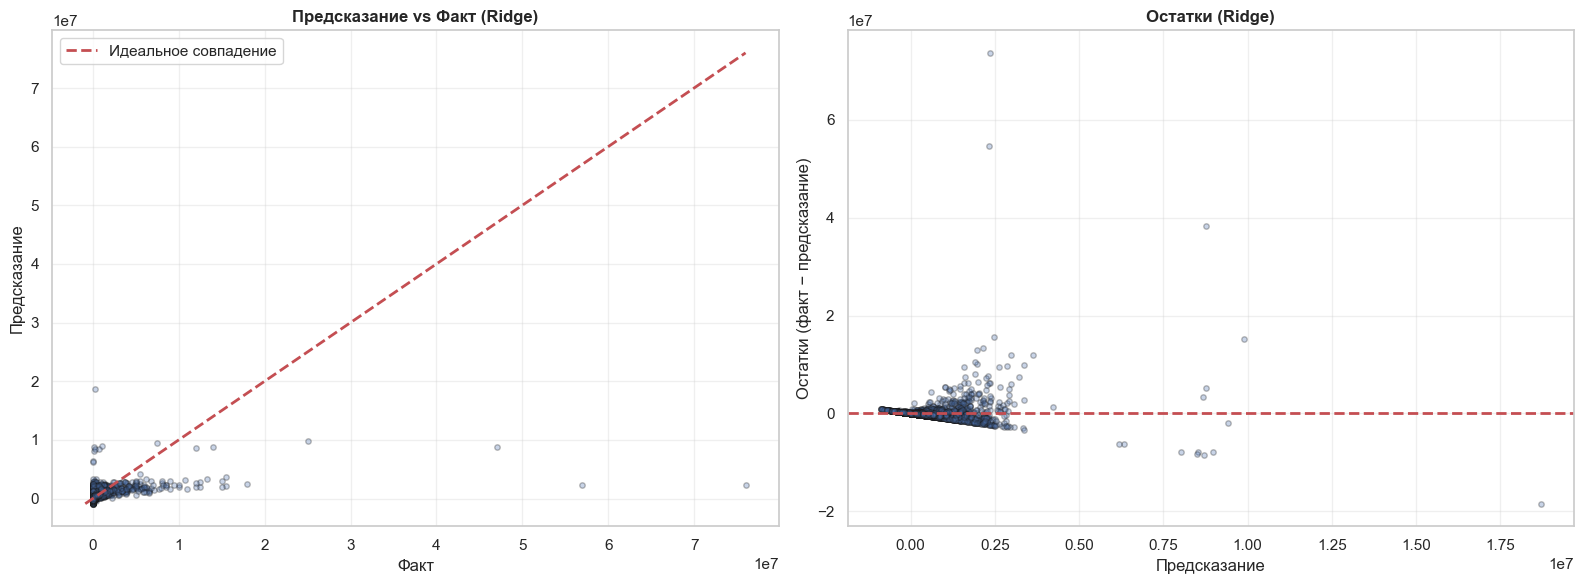

In [49]:
y_val_pred = best_model.predict(X_val_cmp)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Предсказание vs факт
axes[0].scatter(y_val_cmp, y_val_pred, alpha=0.3, edgecolor='k', s=15)
lims = [min(y_val_cmp.min(), y_val_pred.min()),
        max(y_val_cmp.max(), y_val_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Идеальное совпадение')
axes[0].set_xlabel('Факт')
axes[0].set_ylabel('Предсказание')
axes[0].set_title(f'Предсказание vs Факт ({best_name})', fontweight='bold')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Остатки
residuals = y_val_cmp - y_val_pred
axes[1].scatter(y_val_pred, residuals, alpha=0.3, edgecolor='k', s=15)
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Предсказание')
axes[1].set_ylabel('Остатки (факт − предсказание)')
axes[1].set_title(f'Остатки ({best_name})', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("best_model_diagnostics.png", dpi=120, bbox_inches='tight')
plt.show()

# Важность признаков / коэффициенты

Всего признаков: 3480


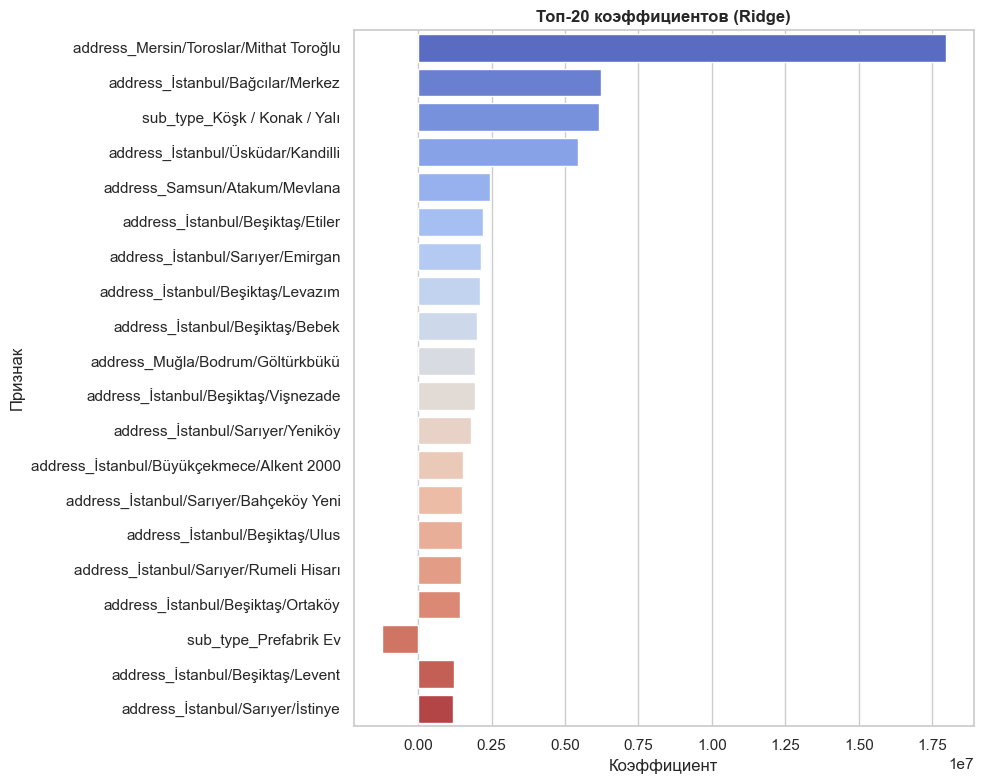

In [50]:
def get_feature_names(preprocessor, num_cols, cat_cols):
    try:
        enc = preprocessor.named_transformers_['cat'].named_steps['onehot']
        cat_names = enc.get_feature_names_out(cat_cols).tolist()
    except Exception:
        cat_names = []
    return list(num_cols) + cat_names

feature_names = get_feature_names(preprocessor, numeric_features, categorical_features)
print(f"Всего признаков: {len(feature_names)}")

# Для деревянных моделей — feature_importances_
if best_name in ('Random Forest', 'Decision Tree'):
    importances = best_model.feature_importances_
    fi_df = pd.DataFrame({
        'Признак': feature_names,
        'Важность': importances,
    }).sort_values('Важность', ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi_df, x='Важность', y='Признак', palette='viridis')
    plt.title(f'Топ-20 важных признаков ({best_name})', fontweight='bold')
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("\nТоп-10 признаков:")
    print(fi_df.head(10).to_string(index=False))

# Для линейной модели — коэффициенты
elif best_name == 'Ridge':
    coef_df = pd.DataFrame({
        'Признак': feature_names,
        'Коэффициент': best_model.coef_,
    })
    coef_df['|Коэф|'] = coef_df['Коэффициент'].abs()
    coef_df = coef_df.sort_values('|Коэф|', ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=coef_df, x='Коэффициент', y='Признак', palette='coolwarm')
    plt.title(f'Топ-20 коэффициентов ({best_name})', fontweight='bold')
    plt.tight_layout()
    plt.savefig("linear_coefficients.png", dpi=120, bbox_inches='tight')
    plt.show()

# Для KNN — permutation importance (на маленькой подвыборке!)
elif best_name == 'KNN':
    from sklearn.inspection import permutation_importance

    X_perm, y_perm = resample(X_val_cmp, y_val_cmp, n_samples=1000,
                              random_state=RANDOM_STATE, replace=False)
    perm = permutation_importance(
        best_model, X_perm, y_perm,
        n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1
    )
    fi_df = pd.DataFrame({
        'Признак': feature_names,
        'Важность': perm.importances_mean,
    }).sort_values('Важность', ascending=False).head(20)

    plt.figure(figsize=(10, 8))
    sns.barplot(data=fi_df, x='Важность', y='Признак', palette='viridis')
    plt.title('Топ-20 признаков (KNN, permutation importance)', fontweight='bold')
    plt.tight_layout()
    plt.savefig("knn_feature_importance.png", dpi=120, bbox_inches='tight')
    plt.show()

# Выбор финальной модели и сохранение

In [51]:
# Тестовая подвыборка — для честного сравнения
N_TEST = 10000
X_test_cmp, y_test_cmp = resample(
    X_test_prep, y_test,
    n_samples=N_TEST,
    random_state=RANDOM_STATE,
    replace=False
)

test_results = [evaluate(name, model, X_test_cmp, y_test_cmp, n_features)
                for name, model in models]

test_df = pd.DataFrame(test_results).set_index('Модель').round(3)
print("\n" + "=" * 60)
print("ФИНАЛЬНАЯ ОЦЕНКА (тест, подвыборка 10 000)")
print("=" * 60)
print(test_df.to_string())
test_df.to_csv("model_comparison_test.csv")


ФИНАЛЬНАЯ ОЦЕНКА (тест, подвыборка 10 000)
                     MAE       RMSE  MAPE (%)   R²  Adj R²      MedAE  Время предсказания (с)
Модель                                                                                       
Ridge         271,986.21 905,274.60 10,397.89 0.22   -0.20 140,832.69                    0.00
Random Forest 253,323.38 927,193.69  7,624.12 0.18   -0.26 163,068.36                    0.07
KNN           199,704.53 952,093.23    306.31 0.14   -0.33  54,350.00                    6.85


# Обоснование выбора финальной модели

In [52]:
final_name = test_df['RMSE'].idxmin()
final_model = dict(models)[final_name]

print(f"\n Финальная модель: {final_name}")
print(f"   RMSE = {test_df.loc[final_name, 'RMSE']:,.2f}")
print(f"   MAE  = {test_df.loc[final_name, 'MAE']:,.2f}")
print(f"   MAPE = {test_df.loc[final_name, 'MAPE (%)']:.2f}%")
print(f"   R²   = {test_df.loc[final_name, 'R²']:.4f}")
print(f"   Время предсказания: {test_df.loc[final_name, 'Время предсказания (с)']:.3f} сек")


 Финальная модель: Ridge
   RMSE = 905,274.60
   MAE  = 271,986.21
   MAPE = 10397.89%
   R²   = 0.2190
   Время предсказания: 0.001 сек


# Сохранение финальной модели

In [53]:
import joblib

joblib.dump(final_model,          "final_model.pkl")
joblib.dump(preprocessor,         "preprocessor.pkl")           # ОБУЧЕННЫЙ!
joblib.dump(numeric_features,     "numeric_features.pkl")
joblib.dump(categorical_features, "categorical_features.pkl")

print("\nСохранено:")
print("  — final_model.pkl")
print("  — preprocessor.pkl (обученный)")
print("  — numeric_features.pkl")
print("  — categorical_features.pkl")


Сохранено:
  — final_model.pkl
  — preprocessor.pkl (обученный)
  — numeric_features.pkl
  — categorical_features.pkl


# Проверка: загрузка и предсказание

In [54]:
loaded_model = joblib.load("final_model.pkl")
loaded_prep  = joblib.load("preprocessor.pkl")
loaded_num   = joblib.load("numeric_features.pkl")
loaded_cat   = joblib.load("categorical_features.pkl")

# Берём 5 объектов из теста
sample = X_test.iloc[:5].copy()

# Та же очистка, что при обучении
for col in loaded_num:
    sample[col] = pd.to_numeric(sample[col], errors='coerce')
for col in loaded_cat:
    sample[col] = sample[col].astype(str)

# Трансформация и предсказание
sample_prep = loaded_prep.transform(sample)
preds = loaded_model.predict(sample_prep)

print("Предсказания для 5 объектов:")
print(preds)
print("\nФактические значения:")
print(y_test.iloc[:5].values)
print("\nОтклонение:")
print(np.abs(preds - y_test.iloc[:5].values))

Предсказания для 5 объектов:
[-302034.35364656  363056.51941511  -92706.47007373   58454.45391882
 -227073.20546819]

Фактические значения:
[  1050. 325000. 120000.   1700.   1000.]

Отклонение:
[303084.35364656  38056.51941511 212706.47007373  56754.45391882
 228073.20546819]


Важные нюансы по каждой модели
Ridge (линейная)
+ Быстрое обучение и предсказание.

+ Интерпретируемые коэффициенты.

+ Устойчива к переобучению благодаря L2-регуляризации.

− Плохо работает с нелинейными зависимостями.

− Чувствительна к масштабу (уже обработано StandardScaler).

Random Forest (бэггинг)
+ Хорошее качество на табличных данных.

+ Устойчив к выбросам и нелинейностям.

+ Даёт feature importance.

− Медленнее линейных моделей.

− Большой размер модели (десятки МБ).

− Может переобучаться без max_depth и min_samples_leaf.

KNN (ленивый алгоритм)
+ Простая идея, нет обучения как такового.

+ Хорошо работает на маленьких данных.

− Очень медленный predict на больших данных (O(N×D)).

− Проклятие размерности: при >50 признаков качество падает.

− Чувствителен к масштабу и выбросам.

− Нет интерпретации.

− Большой размер модели (хранит все обучающие точки).